In [ ]:
from typing import List
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

from ccxt.binance import binance
from ccxt.hyperliquid import hyperliquid
from ccxt.lighter import lighter

from siglab_py.util.market_data_util import fetch_candles
from siglab_py.util.analytic_util import compute_candles_stats

VALIDATION_MAX_GAPS = 20

In [2]:
start_date = datetime(2026, 5,1)
end_date = datetime(2026,5,29,0,0,0)
exchange = lighter()
candle_size = "1h"

## Fetch Candles and Calculate TA

In [ ]:
all_candles_w_ta = {}
all_orderbooks = {}
crypto_tickers = [ "BTC/USDC:USDC", "ETH/USDC:USDC", "SOL/USDC:USDC", "DOGE/USDC:USDC", "HYPE/USDC:USDC" ]
commodities_tickers = [ "XAU/USDC:USDC", "XAG/USDC:USDC" ]
tradfi_tickers = [ "AMZN/USDC:USDC", "GOOGL/USDC:USDC", "META/USDC:USDC", "MSFT/USDC:USDC", "MSTR/USDC:USDC", "TSLA/USDC:USDC", "NVDA/USDC:USDC", "QQQ/USDC:USDC", "SPY/USDC:USDC" ]
fx_tickers = [ "EURUSD/USDC:USDC", "GBPUSD/USDC:USDC", "AUDUSD/USDC:USDC", "NZDUSD/USDC:USDC", "USDJPY/USDC:USDC", "USDCHF/USDC:USDC", "USDCAD/USDC:USDC" ]
tickers = fx_tickers + crypto_tickers + commodities_tickers + tradfi_tickers
for ticker in tickers:
    candles = fetch_candles(
                                                    start_ts=int(start_date.timestamp()), 
                                                    end_ts=int(end_date.timestamp()), 
                                                    exchange=exchange, normalized_symbols=[ticker], 
                                                    candle_size = candle_size, 
                                                    num_candles_limit = 100,
                                                    validation_max_gaps = VALIDATION_MAX_GAPS, # some newly listed FX pairs gaps
                                                    logger = None
                                                )
    pd_candles = candles[ticker]
    compute_candles_stats(
            pd_candles=pd_candles,
            boillenger_std_multiples=2,
            sliding_window_how_many_candles=24,
            validation_max_gaps = VALIDATION_MAX_GAPS, # some newly listed FX pairs gaps
            pypy_compat=False
        )

    all_candles_w_ta[ticker] = pd_candles

    print(f"Done fetch candles + calculate TA for {ticker}")

    all_orderbooks[ticker] = exchange.fetch_order_book(symbol=ticker)

# ATR

### Crypto + Commodities

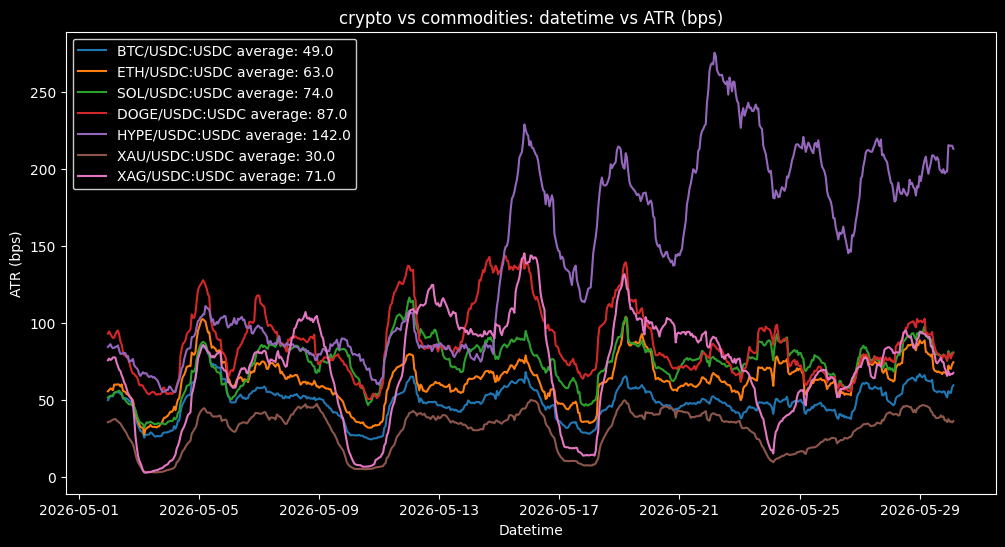

In [4]:
NUM_DAYS = 24*90
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(12, 6), facecolor='black')
ax1.set_facecolor('black')

colors = plt.cm.tab10(range(len(crypto_tickers + commodities_tickers)))

for i, ticker in enumerate(crypto_tickers + commodities_tickers):
    pd_candles = all_candles_w_ta[ticker]
    selected = pd_candles.iloc[-NUM_DAYS:]
    ax1.set_xlabel('Datetime', color='white')
    ax1.set_ylabel('ATR (bps)', color='white')
    ax1.plot(selected['datetime'], selected['atr_bps'], color=colors[i], label=f"{ticker} average: {round(selected['atr_bps'].mean(),0)}")
    ax1.tick_params(axis='y', colors='white')
    ax1.tick_params(axis='x', colors='white')
    ax1.legend(loc='upper left', facecolor='black', edgecolor='white')

plt.title(f'crypto vs commodities: datetime vs ATR (bps)')
plt.show()

## Flow snapshot

In [28]:
max_slippage_bps = 2

tip_of_the_book = []
for ticker in tickers:
    ob = all_orderbooks[ticker]
    bids = ob['bids']
    asks = ob['asks'] 
    best_bid = max([ bid[0] for bid in bids ])
    best_ask = min([ ask[0] for ask in asks ])
    best_bid_volume_base_ccy = sum([ bid[1] for bid in bids if bid[0]>=best_bid*(1 - max_slippage_bps/10000) ])
    best_bid_volume_usd = int(best_bid_volume_base_ccy * best_bid)
    best_ask_volume_base_ccy = sum([ ask[1] for ask in asks if ask[0]<=best_ask*(1 + max_slippage_bps/10000)])
    best_ask_volume_usd = int(best_ask_volume_base_ccy * best_ask)

    tip_of_the_book.append({
            'ticker' : ticker,
            'best_bid' : best_bid,
            'best_ask' : best_ask,
            'best_bid_volume_base_ccy' : round(best_bid_volume_base_ccy, 2),
            'best_bid_volume_usd' : best_bid_volume_usd,
            'best_ask_volume_base_ccy' : round(best_ask_volume_base_ccy, 2),
            'best_ask_volume_usd' : best_ask_volume_usd,
            'total_volume_usd' : best_bid_volume_usd + best_ask_volume_usd,
            'min_volume_usd' : min(best_bid_volume_usd, best_ask_volume_usd),
        }
    )

pd_tip_of_the_book = pd.DataFrame(tip_of_the_book)
pd_tip_of_the_book.sort_values(
    by=['min_volume_usd'], 
    ascending=False,
    inplace=True
)

pd_tip_of_the_book_styled = pd_tip_of_the_book[['ticker', 'best_bid_volume_usd', 'best_ask_volume_usd', 'min_volume_usd']].style.format({
    'best_bid_volume_usd': '{:,.0f}',
    'best_ask_volume_usd': '{:,.0f}',
    'min_volume_usd' : '{:,.0f}',
})
pd_tip_of_the_book_styled

,ticker,best_bid_volume_usd,best_ask_volume_usd,min_volume_usd
8,ETH/USDC:USDC,"1,326,715","1,173,001","1,173,001"
7,BTC/USDC:USDC,"1,074,894","629,905","629,905"
12,XAU/USDC:USDC,"34,640","28,994","28,994"
20,NVDA/USDC:USDC,"34,443","28,342","28,342"
9,SOL/USDC:USDC,"228,695","23,135","23,135"
11,HYPE/USDC:USDC,"66,448","18,115","18,115"
0,EURUSD/USDC:USDC,"27,794","7,997","7,997"
22,SPY/USDC:USDC,"101,354","7,179","7,179"
17,MSFT/USDC:USDC,"6,453","20,736","6,453"
19,TSLA/USDC:USDC,"5,534","10,794","5,534"


### ATR histogram

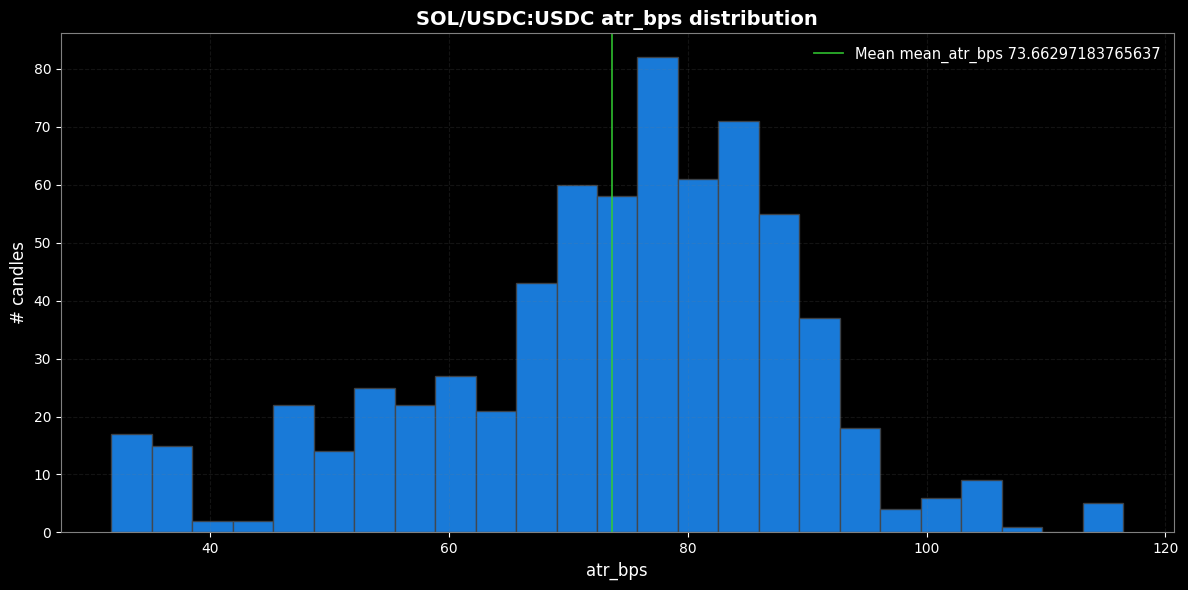

In [6]:
ticker = "SOL/USDC:USDC"
pd_candles = all_candles_w_ta[ticker]

plt.figure(figsize=(12, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.hist(
    pd_candles['atr_bps'],
    
    bins=25,
    edgecolor='#444444',
    alpha=0.85,
    color='dodgerblue'
)

mean_atr_bps = pd_candles['atr_bps'].mean()
plt.axvline(mean_atr_bps, color='limegreen', linestyle='-', linewidth=1.3, alpha=0.85,
            label=f'Mean mean_atr_bps {mean_atr_bps}')

plt.title(f'{ticker} atr_bps distribution', 
          fontsize=14, fontweight='bold', color='white')
plt.xlabel('atr_bps', fontsize=12, color='white')
plt.ylabel('# candles', fontsize=12, color='white')

plt.grid(True, alpha=0.15, linestyle='--', color='gray')
plt.legend(loc='upper right', frameon=False, fontsize=10.5, labelcolor='white')

ax.tick_params(colors='white', which='both')
ax.spines['bottom'].set_color('gray')
ax.spines['top'].set_color('gray')
ax.spines['left'].set_color('gray')
ax.spines['right'].set_color('gray')

plt.tight_layout()
plt.show()

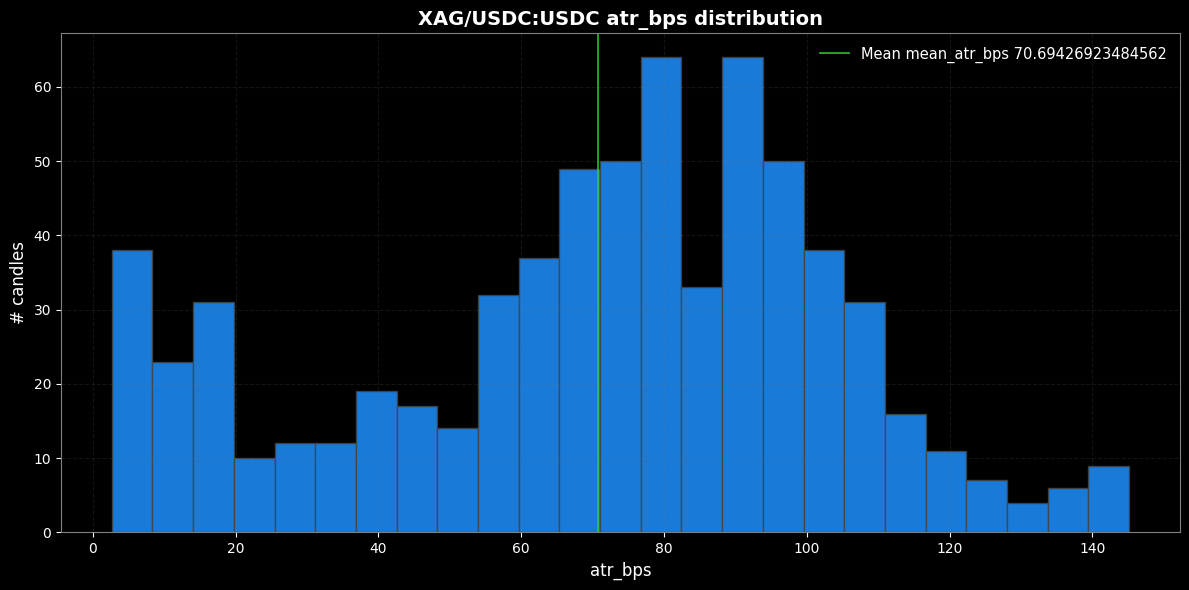

In [7]:
ticker = "XAG/USDC:USDC"
pd_candles = all_candles_w_ta[ticker]

plt.figure(figsize=(12, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.hist(
    pd_candles['atr_bps'],
    
    bins=25,
    edgecolor='#444444',
    alpha=0.85,
    color='dodgerblue'
)

mean_atr_bps = pd_candles['atr_bps'].mean()
plt.axvline(mean_atr_bps, color='limegreen', linestyle='-', linewidth=1.3, alpha=0.85,
            label=f'Mean mean_atr_bps {mean_atr_bps}')

plt.title(f'{ticker} atr_bps distribution', 
          fontsize=14, fontweight='bold', color='white')
plt.xlabel('atr_bps', fontsize=12, color='white')
plt.ylabel('# candles', fontsize=12, color='white')

plt.grid(True, alpha=0.15, linestyle='--', color='gray')
plt.legend(loc='upper right', frameon=False, fontsize=10.5, labelcolor='white')

ax.tick_params(colors='white', which='both')
ax.spines['bottom'].set_color('gray')
ax.spines['top'].set_color('gray')
ax.spines['left'].set_color('gray')
ax.spines['right'].set_color('gray')

plt.tight_layout()
plt.show()

### Tradfi

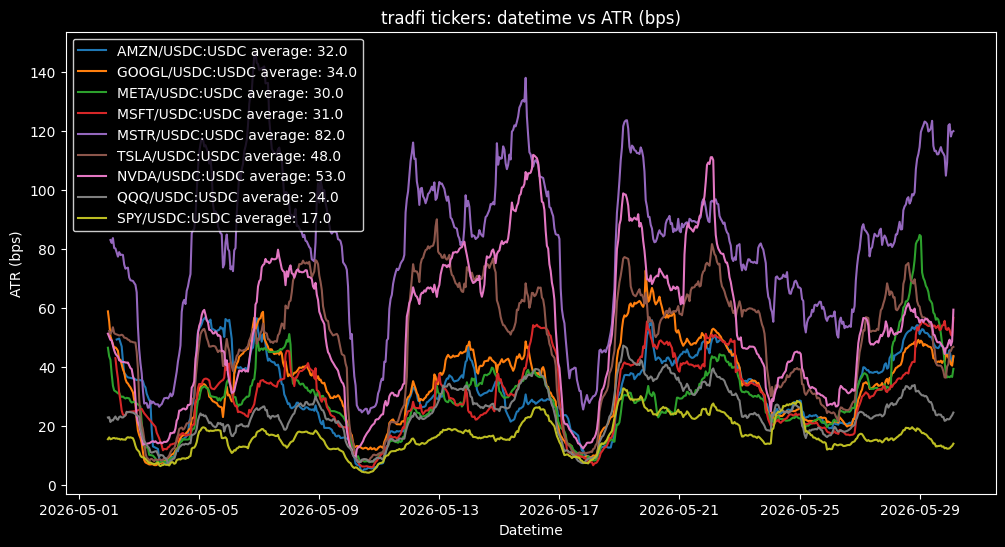

In [8]:
NUM_DAYS = 24*365
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(12, 6), facecolor='black')
ax1.set_facecolor('black')

colors = plt.cm.tab10(range(len(tradfi_tickers)))

for i, ticker in enumerate(tradfi_tickers):
    pd_candles = all_candles_w_ta[ticker]
    selected = pd_candles.iloc[-NUM_DAYS:]
    ax1.set_xlabel('Datetime', color='white')
    ax1.set_ylabel('ATR (bps)', color='white')
    ax1.plot(selected['datetime'], selected['atr_bps'], color=colors[i], label=f"{ticker} average: {round(selected['atr_bps'].mean(),0)}")
    ax1.tick_params(axis='y', colors='white')
    ax1.tick_params(axis='x', colors='white')
    ax1.legend(loc='upper left', facecolor='black', edgecolor='white')

plt.title(f'tradfi tickers: datetime vs ATR (bps)')
plt.show()

### FX

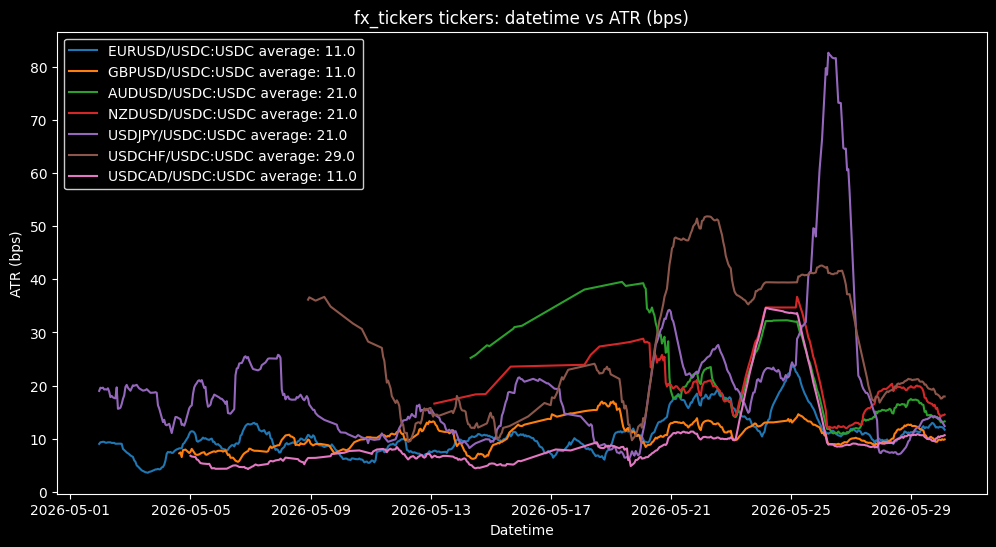

In [9]:
NUM_DAYS = 24*365
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(12, 6), facecolor='black')
ax1.set_facecolor('black')

colors = plt.cm.tab10(range(len(fx_tickers)))

for i, ticker in enumerate(fx_tickers):
    pd_candles = all_candles_w_ta[ticker]
    selected = pd_candles.iloc[-NUM_DAYS:]
    ax1.set_xlabel('Datetime', color='white')
    ax1.set_ylabel('ATR (bps)', color='white')
    ax1.plot(selected['datetime'], selected['atr_bps'], color=colors[i], label=f"{ticker} average: {round(selected['atr_bps'].mean(),0)}")
    ax1.tick_params(axis='y', colors='white')
    ax1.tick_params(axis='x', colors='white')
    ax1.legend(loc='upper left', facecolor='black', edgecolor='white')

plt.title(f'fx_tickers tickers: datetime vs ATR (bps)')
plt.show()